#REDES MULTICAPA



El dataset escogido guarda información sobre las características de diferentes  tipos de teléfonos móviles de segunda mano y los clasifica en unos rangos de precio.

##Carga y comprobación del dataset

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import SGD, Adam, RMSprop

import warnings

warnings.filterwarnings('ignore')

In [ ]:
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt

%matplotlib inline

# **Guardar y acceder a los datos**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
RUTA1 = '/content/drive/MyDrive/ESPECIALISTA IA/mobiles_sale.csv'

data = pd.read_csv(RUTA1)



In [ ]:
data.head()

,battery_power,blue,clock_speed,dual_sim,fc,five_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,four_g,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,2
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,2
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   five_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  four_g         2000 non-null   int64  
 18  price_ra

In [ ]:
data.describe()

,battery_power,blue,clock_speed,dual_sim,fc,five_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,four_g,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,9.916500,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,6.064315,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,0.000000,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,5.000000,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,10.000000,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,15.000000,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,20.000000,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,3.000000


**Comprobamos reparto valores de la variable target**

In [ ]:
data.price_range.value_counts()

,count
price_range,
1,500
2,500
3,500
0,500


**Comprobamos codificacion correcta de las variables binarias.**

In [ ]:
atrib_bool = ['four_g','five_g','dual_sim','blue']

for atrib in atrib_bool:
    print(data[atrib].name,':\n',data[atrib].value_counts())
    print('-------'*6)

four_g :
 four_g
1    1523
0     477
Name: count, dtype: int64
------------------------------------------
five_g :
 five_g
1    1043
0     957
Name: count, dtype: int64
------------------------------------------
dual_sim :
 dual_sim
1    1019
0     981
Name: count, dtype: int64
------------------------------------------
blue :
 blue
0    1010
1     990
Name: count, dtype: int64
------------------------------------------


**Debemos recordar que trabajando con TF y Keras necesitamos los atributos y el target como numpy arrays:**

In [ ]:
data.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'five_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'four_g',
       'price_range'],
      dtype='object')

In [ ]:
# obtenemos ya los atributos y el target como numpy arrays

features = data.iloc[:,:18].values
labels = data.iloc[:,18].values

## 1. Pre-procesado

Todos los atributos de este dataset son numéricos.

Solo falta escalar sus valores a un mismo rango (entre cero y uno), condición necesaria en las redes neuronales.

Para la variable objetivo Keras tiene un método apropiado (nº salidas)

Binarizamos variable target (4 salidas indicando la pertenencia a cada clase):

In [ ]:
from keras.utils import to_categorical

labels = to_categorical(labels)
labels.shape

(2000, 4)

Normalizamos atributos rango [0,1]:

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

features = scaler.fit_transform(features)

pd.DataFrame(features).describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.492664,0.4950,0.408900,0.509500,0.226816,0.521500,0.484621,0.446389,0.502075,0.502929,0.495825,0.329137,0.501679,0.499255,0.521893,0.320389,0.500611,0.761500
std,0.293533,0.5001,0.326402,0.500035,0.228497,0.499662,0.292673,0.320462,0.294997,0.326834,0.303216,0.226419,0.288518,0.289880,0.300946,0.242022,0.303553,0.426273
min,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.234302,0.0000,0.080000,0.000000,0.052632,0.000000,0.225806,0.111111,0.241667,0.285714,0.250000,0.144260,0.250167,0.254276,0.285714,0.111111,0.222222,1.000000
50%,0.484302,0.0000,0.400000,1.000000,0.157895,1.000000,0.483871,0.444444,0.508333,0.428571,0.500000,0.287755,0.498665,0.505211,0.500000,0.277778,0.500000,1.000000
75%,0.744322,1.0000,0.680000,1.000000,0.368421,1.000000,0.741935,0.777778,0.750000,0.857143,0.750000,0.483291,0.756342,0.750534,0.785714,0.500000,0.777778,1.000000
max,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Ahora realizamos la partición TRAIN-TEST:

In [ ]:
train_x, test_x, train_y, test_y = train_test_split(features, labels, test_size=0.2)

## 2. Influencia del nº de epochs y "learning rate"

Vamos a probar primero con una red con la siguiente arquitectura:

   - 2 capas ocultas con 25 y 15 neuronas sucesivamente
   - Función de activación de las capas intermedias 'relu' (usual)
   - Función de activación de salida 'softmax' (ya que es clasificación multiclase)
   - Usaremos las inicializaciones de pesos más frecuentes
   - Para la capa de entrada debemos fijarnos en nuestros datos (features)
   


In [ ]:
features.shape

(2000, 18)

**Creamos el modelo pedido:**

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import SGD, Adam, RMSprop



In [ ]:
# creamos modelo
model2_1 = Sequential()


#capas ocultas
model2_1.add(Dense(25, input_shape=(features.shape[1],), activation="relu"))

model2_1.add(Dense(15, activation="relu", kernel_initializer="he_normal",bias_initializer="zeros"))


#capa salida
model2_1.add(Dense(4, activation="softmax", kernel_initializer="glorot_normal",bias_initializer="zeros"))



Podemos obtener **información** de nuestro **modelo** con el **método "summary"**:

In [ ]:
model2_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 25)                  │             475 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 15)                  │             390 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │              64 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)


**El siguiente paso es COMPILAR nuestra red, pasándole los siguientes datos:**

   - Como optimizador elegimos "Adam" con "learning-rate" de "1"
   - La función de pérdida en el caso de clasificación multiclase es 'categorical_crossentropy'
   - Tomamos como métrica adicional "accuracy"


In [ ]:
# compilamos el modelo

model2_1.compile(optimizer=Adam(learning_rate=1.0), loss='categorical_crossentropy', metrics=['accuracy'])



**El último paso es entrenar nuestra red, donde podemos especificar:**

   - La proporción de la partición de validación (dentro de TRAIN)
   - Número de epochs
   - Tamaño del "batch"

In [ ]:
train_x.shape, train_y.shape

((1600, 18), (1600, 4))

In [ ]:
# entrenamos la red

history = model2_1.fit(train_x, train_y, validation_split=0.2, epochs=10, verbose=2)

Epoch 1/10
40/40 - 3s - 75ms/step - accuracy: 0.2414 - loss: 9.1594 - val_accuracy: 0.2469 - val_loss: 1.5013
Epoch 2/10
40/40 - 1s - 20ms/step - accuracy: 0.2352 - loss: 1.4256 - val_accuracy: 0.2188 - val_loss: 1.4251
Epoch 3/10
40/40 - 0s - 7ms/step - accuracy: 0.2570 - loss: 1.4232 - val_accuracy: 0.2188 - val_loss: 1.5109
Epoch 4/10
40/40 - 0s - 5ms/step - accuracy: 0.2484 - loss: 1.4309 - val_accuracy: 0.2812 - val_loss: 1.4073
Epoch 5/10
40/40 - 0s - 6ms/step - accuracy: 0.2539 - loss: 1.4527 - val_accuracy: 0.2812 - val_loss: 1.4110
Epoch 6/10
40/40 - 0s - 5ms/step - accuracy: 0.2219 - loss: 1.4379 - val_accuracy: 0.2531 - val_loss: 1.4394
Epoch 7/10
40/40 - 0s - 5ms/step - accuracy: 0.2555 - loss: 1.4534 - val_accuracy: 0.2531 - val_loss: 1.4508
Epoch 8/10
40/40 - 0s - 7ms/step - accuracy: 0.2594 - loss: 1.4398 - val_accuracy: 0.2469 - val_loss: 1.3937
Epoch 9/10
40/40 - 0s - 4ms/step - accuracy: 0.2570 - loss: 1.4326 - val_accuracy: 0.2469 - val_loss: 1.4148
Epoch 10/10
40/40

**Creamos función de utilidad para el resto de la práctica:**

In [ ]:
def plot_train_results(history):

    # Visualizamos la evolución de la accuracy
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='lower right')
    plt.grid = True
    plt.show()

    # Visualizamos la evolución del error cometido por la red
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper right')
    plt.grid = True
    plt.show()



**Dibujamos las gráficas.**

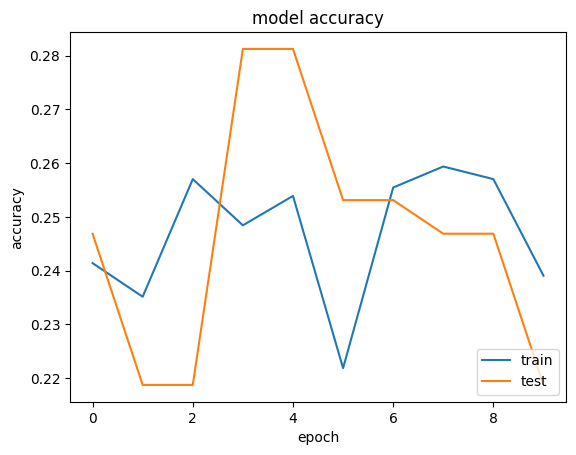

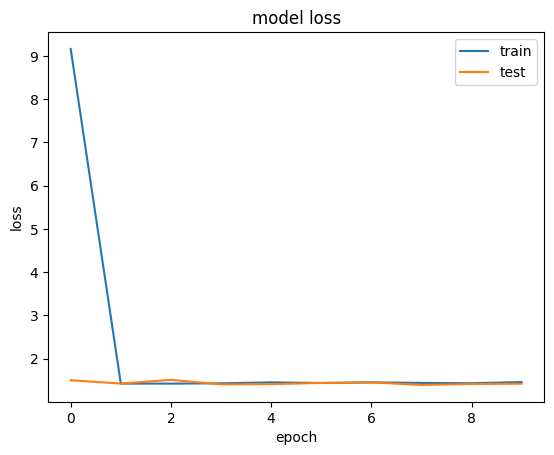

In [ ]:
plot_train_results(history)

**CONCLUSIONES**:

* Valor del **"learning rate"** demasiado elevado (1.0): vemos oscilaciones en la curva de pérdida, acompañadas de oscilaciones muy pronunciadas en las de "accuracy"

* Valores de "accuracy" muy bajos: underfitting.
Dado el tamaño del dataset parece que 10 épocas **(epochs)** se hace corto. También puede ayudar (sin excederse) aumentar la complejidad de la red.

In [ ]:
model2_1.evaluate(test_x,test_y)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.2612 - loss: 1.3908


[1.3868275880813599, 0.26249998807907104]

Vamos a hacer las correcciones necesarias:

   - 3 capas ocultas con 25, 20 y 15 neuronas sucesivamente


In [ ]:
# creamos modelo
model2_2 = Sequential()


#capas ocultas
model2_2.add(Dense(25, input_shape=(features.shape[1],), activation="relu"))

model2_2.add(Dense(20, activation="relu", kernel_initializer="he_normal",bias_initializer="zeros"))

model2_2.add(Dense(15, activation="relu", kernel_initializer="he_normal",bias_initializer="zeros"))


#capa salida
model2_2.add(Dense(4, activation="softmax", kernel_initializer="glorot_normal",bias_initializer="zeros"))



In [ ]:
model2_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 25)                  │             475 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 20)                  │             520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 15)                  │             315 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 4)                   │              64 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,374 (5.37 KB)

 Trainable params: 1,374 (5.37 KB)

 Non-trainable params: 0 (0.00 B)

   - Mantenemos "Adam" con "learning-rate" de "0.01"


In [ ]:
# compilamos el modelo

model2_2.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])



   - Número de epochs: 100


In [ ]:
# entrenamos la red

history = model2_2.fit(train_x, train_y, validation_split=0.2, epochs=100, batch_size=int(train_x.shape[0]/4), verbose=2)

Epoch 1/100
4/4 - 4s - 1s/step - accuracy: 0.2375 - loss: 1.4237 - val_accuracy: 0.2937 - val_loss: 1.3760
Epoch 2/100
4/4 - 0s - 20ms/step - accuracy: 0.3164 - loss: 1.3721 - val_accuracy: 0.3719 - val_loss: 1.3607
Epoch 3/100
4/4 - 0s - 33ms/step - accuracy: 0.3977 - loss: 1.3534 - val_accuracy: 0.4000 - val_loss: 1.3316
Epoch 4/100
4/4 - 0s - 34ms/step - accuracy: 0.3797 - loss: 1.3239 - val_accuracy: 0.4875 - val_loss: 1.2671
Epoch 5/100
4/4 - 0s - 35ms/step - accuracy: 0.4867 - loss: 1.2466 - val_accuracy: 0.5344 - val_loss: 1.1550
Epoch 6/100
4/4 - 0s - 35ms/step - accuracy: 0.5305 - loss: 1.1210 - val_accuracy: 0.5969 - val_loss: 0.9786
Epoch 7/100
4/4 - 0s - 35ms/step - accuracy: 0.6039 - loss: 0.9542 - val_accuracy: 0.6562 - val_loss: 0.8112
Epoch 8/100
4/4 - 0s - 32ms/step - accuracy: 0.6727 - loss: 0.7970 - val_accuracy: 0.7469 - val_loss: 0.6731
Epoch 9/100
4/4 - 0s - 35ms/step - accuracy: 0.7500 - loss: 0.6612 - val_accuracy: 0.7563 - val_loss: 0.5841
Epoch 10/100
4/4 - 0s

**Dibujamos las gráficas.**

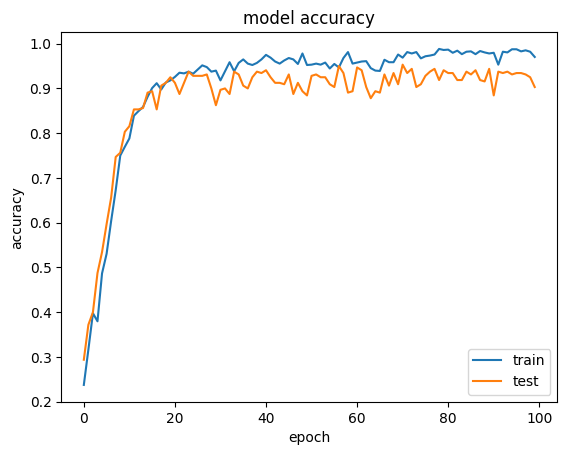

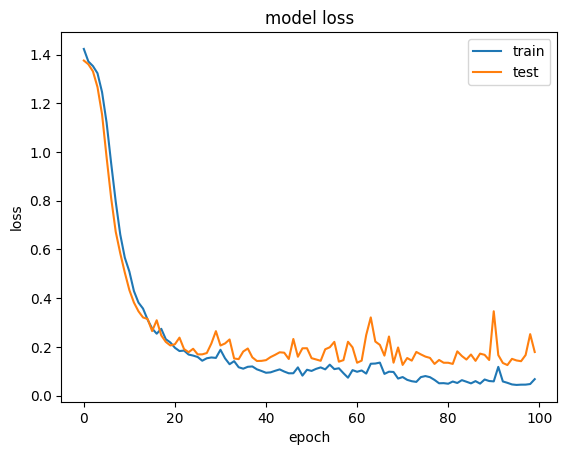

In [ ]:
plot_train_results(history)

**CONCLUSIONES**:

* **Estabilidad "learning rate"**: Vemos en primer lugar que las oscilaciones en ambas curvas son menos pronunciadas, de hecho podemos observar el comportamiento conocido de ligero sobreentrenamiento

* Valores de "accuracy" mucho mejores, llegando al overfitting: **Se ha añadido el nº de epochs suficiente** y se ha añadido algo de complejidad a la red.

In [ ]:
model2_2.evaluate(test_x,test_y)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9136 - loss: 0.2232


[0.21219366788864136, 0.9049999713897705]

## 3. Número de neuronas (complejidad de la red)

Partimos de los mismos valores anteriores, excepto la arquitectura (nº de neuronas para 2 capas internas) conlas siguientes dimensiones:

   - Modelo 1: [20, 16, 12, 4]
   - Modelo 2: [20, 1024, 512, 4]
   

### Modelo 1

In [ ]:
# creamos modelo
model3_1 = Sequential()


#capas ocultas
model3_1.add(Dense(20, input_shape=(features.shape[1],), activation="relu"))

model3_1.add(Dense(16, activation="relu", kernel_initializer="he_normal",bias_initializer="zeros"))

model3_1.add(Dense(12, activation="relu", kernel_initializer="he_normal",bias_initializer="zeros"))


#capa salida
model3_1.add(Dense(4, activation="softmax", kernel_initializer="glorot_normal",bias_initializer="zeros"))


# compilamos el modelo

model3_1.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model3_1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                      │ (None, 20)                  │             380 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 16)                  │             336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 12)                  │             204 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 4)                   │              52 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 972 (3.80 KB)

 Trainable params: 972 (3.80 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# entrenamos la red

history3_1 = model3_1.fit(train_x, train_y, validation_split=0.2, epochs=200, batch_size=int(train_x.shape[0]/4), verbose=2)

Epoch 1/200
4/4 - 4s - 876ms/step - accuracy: 0.2680 - loss: 1.3929 - val_accuracy: 0.3438 - val_loss: 1.3662
Epoch 2/200
4/4 - 0s - 18ms/step - accuracy: 0.3664 - loss: 1.3538 - val_accuracy: 0.3875 - val_loss: 1.3370
Epoch 3/200
4/4 - 0s - 17ms/step - accuracy: 0.4008 - loss: 1.3171 - val_accuracy: 0.4406 - val_loss: 1.2781
Epoch 4/200
4/4 - 0s - 18ms/step - accuracy: 0.4828 - loss: 1.2453 - val_accuracy: 0.4750 - val_loss: 1.1795
Epoch 5/200
4/4 - 0s - 17ms/step - accuracy: 0.5375 - loss: 1.1284 - val_accuracy: 0.5156 - val_loss: 1.0444
Epoch 6/200
4/4 - 0s - 18ms/step - accuracy: 0.5992 - loss: 0.9779 - val_accuracy: 0.6094 - val_loss: 0.8735
Epoch 7/200
4/4 - 0s - 17ms/step - accuracy: 0.6547 - loss: 0.8171 - val_accuracy: 0.6719 - val_loss: 0.7286
Epoch 8/200
4/4 - 0s - 20ms/step - accuracy: 0.7195 - loss: 0.6946 - val_accuracy: 0.7625 - val_loss: 0.6360
Epoch 9/200
4/4 - 0s - 33ms/step - accuracy: 0.7344 - loss: 0.6228 - val_accuracy: 0.7469 - val_loss: 0.6002
Epoch 10/200
4/4 -

**Dibujamos las gráficas:**

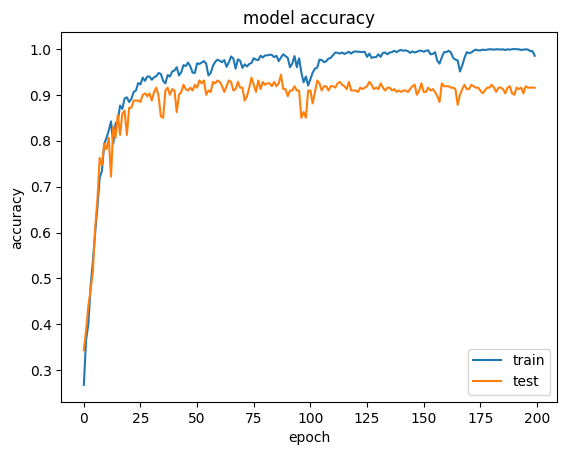

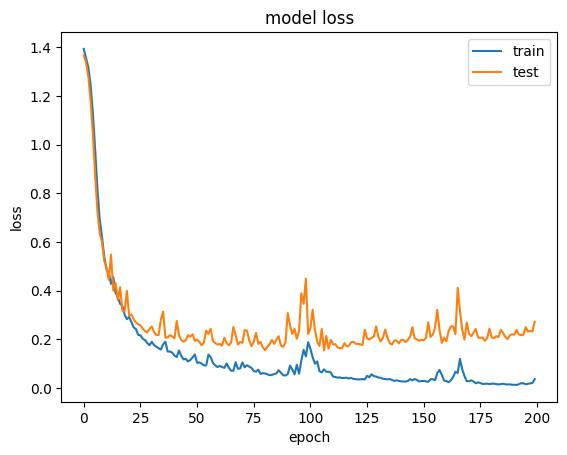

In [ ]:
# gráficas precisión y pérdida
plot_train_results(history3_1)


Se puede ver que aproximadamente sobre los 100 epochs ya entra en overfitting.

In [ ]:
model3_1.evaluate(test_x,test_y)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8833 - loss: 0.3641


[0.35292789340019226, 0.8824999928474426]

### Modelo 2

In [ ]:
# creamos modelo
model3_2 = Sequential()


#capas ocultas
model3_2.add(Dense(20, input_shape=(features.shape[1],), activation="relu"))

model3_2.add(Dense(1024, activation="relu", kernel_initializer="he_normal",bias_initializer="zeros"))

model3_2.add(Dense(512, activation="relu", kernel_initializer="he_normal",bias_initializer="zeros"))


#capa salida
model3_2.add(Dense(4, activation="softmax", kernel_initializer="glorot_normal",bias_initializer="zeros"))


# compilamos el modelo

model3_2.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model3_2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                     │ (None, 20)                  │             380 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 1024)                │          21,504 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 4)                   │           2,052 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 548,736 (2.09 MB)

 Trainable params: 548,736 (2.09 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# entrenamos la red

history3_2 = model3_2.fit(train_x, train_y, validation_split=0.2, epochs=200, batch_size=int(train_x.shape[0]/4), verbose=2)

Epoch 1/200
4/4 - 5s - 1s/step - accuracy: 0.2672 - loss: 6.1266 - val_accuracy: 0.2625 - val_loss: 2.2350
Epoch 2/200
4/4 - 1s - 369ms/step - accuracy: 0.2445 - loss: 1.8515 - val_accuracy: 0.2531 - val_loss: 1.3812
Epoch 3/200
4/4 - 0s - 20ms/step - accuracy: 0.2992 - loss: 1.3668 - val_accuracy: 0.2875 - val_loss: 1.3659
Epoch 4/200
4/4 - 0s - 20ms/step - accuracy: 0.3156 - loss: 1.3639 - val_accuracy: 0.3187 - val_loss: 1.3618
Epoch 5/200
4/4 - 0s - 35ms/step - accuracy: 0.3469 - loss: 1.3296 - val_accuracy: 0.3469 - val_loss: 1.3471
Epoch 6/200
4/4 - 0s - 18ms/step - accuracy: 0.3617 - loss: 1.2932 - val_accuracy: 0.3469 - val_loss: 1.3254
Epoch 7/200
4/4 - 0s - 36ms/step - accuracy: 0.3898 - loss: 1.2665 - val_accuracy: 0.3656 - val_loss: 1.2776
Epoch 8/200
4/4 - 0s - 19ms/step - accuracy: 0.4383 - loss: 1.2088 - val_accuracy: 0.4156 - val_loss: 1.2031
Epoch 9/200
4/4 - 0s - 33ms/step - accuracy: 0.4664 - loss: 1.1318 - val_accuracy: 0.4938 - val_loss: 1.0955
Epoch 10/200
4/4 - 0

**Dibujamos las gráficas:**

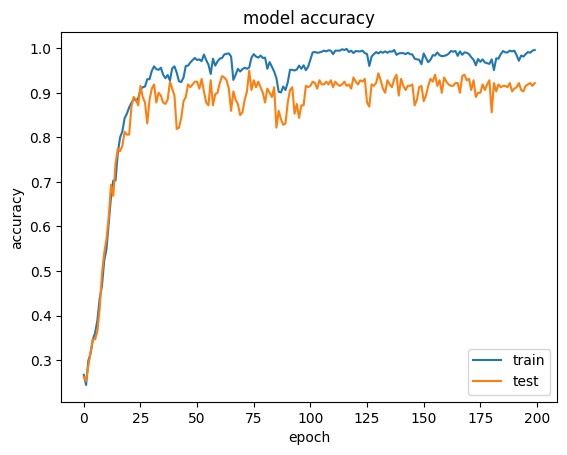

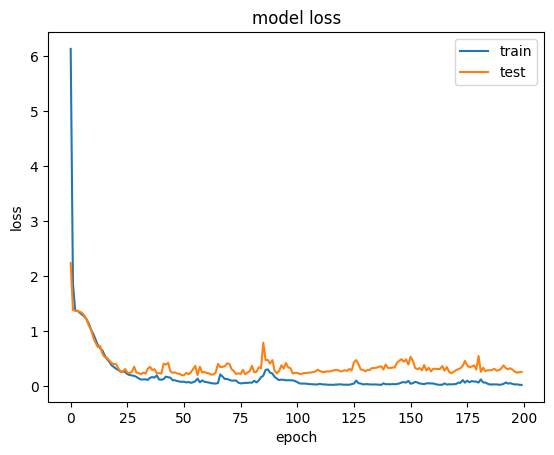

In [ ]:
# gráficas precisión y pérdida
plot_train_results(history3_2)


**CONCLUSIONES**:

* Se ve que en este segundo modelo se ha entrado antes en overfitting (entre 50 y 75 epochs de este último frente a los 100 del primero)

* Valores "val_accuracy"en ambos casos, ¿vale la pena el aumento de complejidad?


Todas conclusiones debidas a la **mayor complejidad** del segundo

In [ ]:
model3_2.evaluate(test_x,test_y)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9088 - loss: 0.4229


[0.3528156280517578, 0.9200000166893005]

## 4. Regularización: DROPOUT

El **Dropout** es una de las **técnicas de regularización** en la que aleatoriamente se selecciona un cierto número de neuronas que serán excluídas del entrenamiento en cada ciclo.

**En la práctica la red se vuelve menos sensible a los pesos** (weights) de las neuronas, **pero también será, en general, más capaz de generalizar mejor y se reducirá el sobreajuste.**

Vamos a ver el efecto que tiene esta regularización en el último de los modelos (el que entraba antes en overfitting). Para ello vamos a añadir una capa de "dropout" con probabilidad p=0.50:

Partimos del modelo 3_2, el que alcanzó antes el sobreentrenamiento. Le añadimos las capas de "dropout".

In [ ]:

# creamos modelo
model4 = Sequential()


#capas ocultas
model4.add(Dense(20, input_shape=(features.shape[1],), activation="relu"))


model4.add(Dense(512, activation="relu", kernel_initializer="he_normal",bias_initializer="zeros"))


model4.add(Dense(250, activation="relu", kernel_initializer="he_normal",bias_initializer="zeros"))
model4.add(Dropout(rate=0.5))


#capa salida
model4.add(Dense(4, activation="softmax", kernel_initializer="glorot_normal",bias_initializer="zeros"))

# compilamos modelo
model4.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])



In [ ]:
model4.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                     │ (None, 20)                  │             380 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 512)                 │          10,752 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 250)                 │         128,250 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 250)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 4)                   │           1,004 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 140,386 (548.38 KB)

 Trainable params: 140,386 (548.38 KB)

 Non-trainable params: 0 (0.00 B)

**Entrenamos y gráfica comparativa.**

In [ ]:
history4 = model4.fit(train_x, train_y, validation_split=0.2, epochs=200, batch_size=int(train_x.shape[0]/4), verbose=2)

Epoch 1/200
4/4 - 4s - 1s/step - accuracy: 0.2234 - loss: 3.5735 - val_accuracy: 0.3750 - val_loss: 1.4738
Epoch 2/200
4/4 - 2s - 483ms/step - accuracy: 0.3164 - loss: 1.5517 - val_accuracy: 0.4375 - val_loss: 1.3001
Epoch 3/200
4/4 - 0s - 34ms/step - accuracy: 0.3703 - loss: 1.3226 - val_accuracy: 0.5031 - val_loss: 1.2033
Epoch 4/200
4/4 - 0s - 18ms/step - accuracy: 0.4289 - loss: 1.2215 - val_accuracy: 0.5188 - val_loss: 1.0997
Epoch 5/200
4/4 - 0s - 19ms/step - accuracy: 0.4711 - loss: 1.1186 - val_accuracy: 0.5875 - val_loss: 0.9933
Epoch 6/200
4/4 - 0s - 36ms/step - accuracy: 0.5117 - loss: 1.0548 - val_accuracy: 0.6125 - val_loss: 0.8965
Epoch 7/200
4/4 - 0s - 32ms/step - accuracy: 0.5492 - loss: 0.9549 - val_accuracy: 0.6375 - val_loss: 0.8278
Epoch 8/200
4/4 - 0s - 26ms/step - accuracy: 0.6102 - loss: 0.8716 - val_accuracy: 0.6656 - val_loss: 0.7265
Epoch 9/200
4/4 - 0s - 40ms/step - accuracy: 0.6453 - loss: 0.7768 - val_accuracy: 0.7375 - val_loss: 0.6536
Epoch 10/200
4/4 - 0

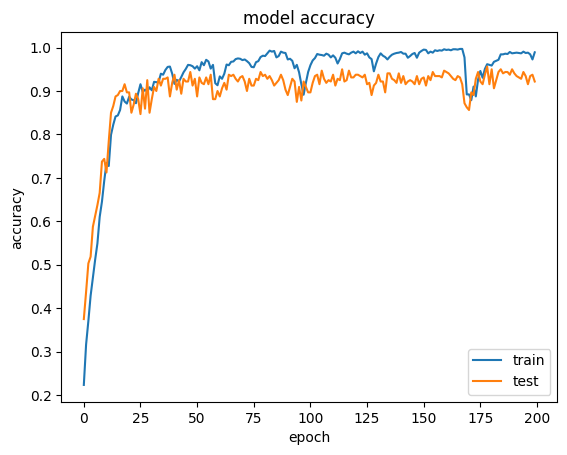

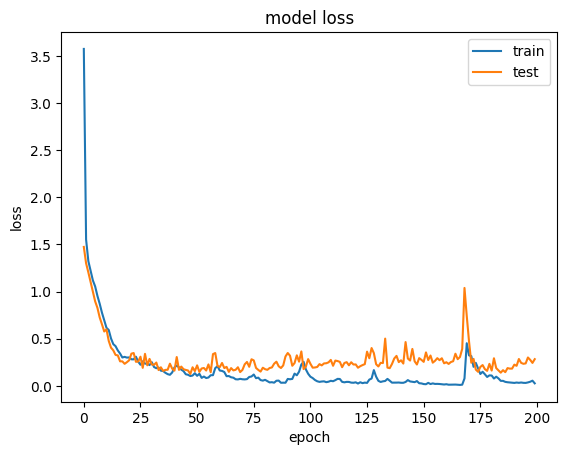

In [ ]:
# gráficas precisión y pérdida
plot_train_results(history4)

**CONCLUSIÓN**

**Utilizando regularización "dropout" el momento de sobreentrenamiento se retrasa** para estar enhtre 75 y 100, mientras que antes (sin DROPOUT) ocurria poco porncima de los 50 (cuando se empiezan a separar las curvas)

In [ ]:
model4.evaluate(test_x,test_y)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8903 - loss: 0.3651


[0.3784160614013672, 0.887499988079071]

## 5. EARLY STOPPING

Keras nos permite detectar cuando no esta mejorando mi modelo en el entrenamiento y parar enese momento el mismo.

Lo hace mediante "callbacks" que pone a nuestra disposición:

In [ ]:
from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='accuracy', patience=5, start_from_epoch=50)

**Se necesita definir explicitamente (no mediante proporción) el conjunto de validación**

In [ ]:
trainval_x, val_x, trainval_y, val_y = train_test_split(train_x, train_y, test_size=0.2)

In [ ]:
# creamos modelo
model3_1_ea = Sequential()


#capas ocultas
model3_1_ea.add(Dense(20, input_shape=(features.shape[1],), activation="relu"))

model3_1_ea.add(Dense(16, activation="relu", kernel_initializer="he_normal",bias_initializer="zeros"))

model3_1_ea.add(Dense(12, activation="relu", kernel_initializer="he_normal",bias_initializer="zeros"))


#capa salida
model3_1_ea.add(Dense(4, activation="softmax", kernel_initializer="glorot_normal",bias_initializer="zeros"))


# compilamos el modelo

model3_1_ea.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# entrenamos la red

history3_1_ea = model3_1_ea.fit(trainval_x, trainval_y, validation_data=(val_x, val_y),
                                epochs=200, batch_size=int(train_x.shape[0]/4), verbose=1,
                                callbacks=early_stopping)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9473 - loss: 0.1270 - val_accuracy: 0.9500 - val_loss: 0.1208
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9657 - loss: 0.1022 - val_accuracy: 0.9406 - val_loss: 0.1191
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9734 - loss: 0.0891 - val_accuracy: 0.9281 - val_loss: 0.1613
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9646 - loss: 0.1005 - val_accuracy: 0.9344 - val_loss: 0.1378
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9653 - loss: 0.0944 - val_accuracy: 0.9438 - val_loss: 0.1256
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9656 - loss: 0.0923 - val_accuracy: 0.9594 - val_loss: 0.1127
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9737 - loss: 0.0837 - val_accuracy: 0.9438 - val_loss: 0.1361
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9492 - loss: 0.1105 - val_accuracy: 0.9094 - val_loss:

In [ ]:
model3_1_ea.evaluate(test_x,test_y)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9330 - loss: 0.1866


[0.2164570391178131, 0.9200000166893005]

Como podemos ver ha parado el entrenamiento antes de los 200 epochs.

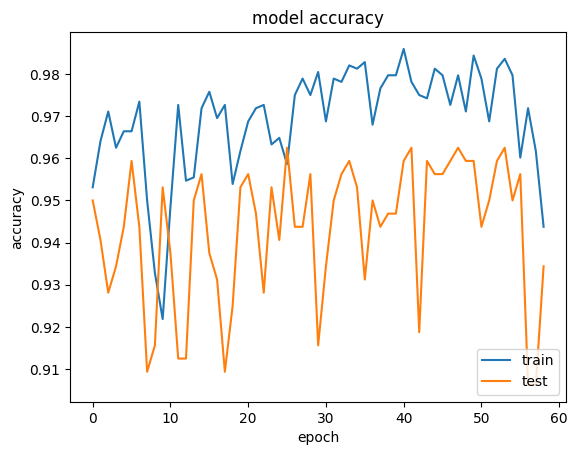

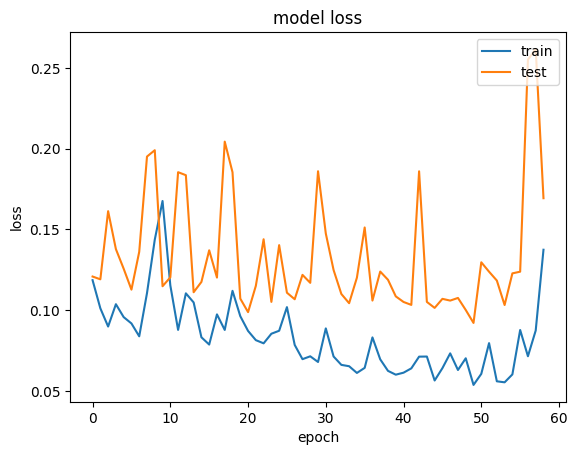

In [ ]:
plot_train_results(history3_1_ea)

##GUARDAR MODELO

Descartando el de sobreentrenamiento temprano, todos tienen valores "accuracy" similares (0.90-0.92). Vamos a guardar este último modelo:

In [ ]:
ruta_modelo = '/content/drive/MyDrive/multicapa.keras'

model3_1_ea.save(ruta_modelo)